# **TASK-ASTE-Preprocessing**

##A_ Theo hướng Genarative
Bạn coi bài toán là "Dịch thuật". Input là câu review, Output là chuỗi văn bản chứa các cặp. Model tự học cách sinh ra từ và ghép cặp.

### 1_ Using `T5`

#####1.1_ Setup & Preparation

In [ ]:
class EduRABSACleaner:
    def __init__(self):
        # Từ điển Slang/Viết tắt thường gặp trong dataset sinh viên
        self.slang_dict = {
            r"\bmc\b": "multiple choice",
            r"\bcuz\b": "because",
            r"\bidk\b": "i do not know",
            r"\blmao\b": "laughing very hard",
            r"\bprof\b": "professor",
            r"\bta\b": "teaching assistant",
            r"\bhw\b": "homework",
            r"\bpts\b": "points"
        }

        # Từ điển Emoticon -> Token cảm xúc (Quan trọng cho T5 hiểu ngữ cảnh)
        self.emoji_dict = {
            ":)": " [smile] ",
            "(:": " [smile] ",
            "C:": " [smile] ",
            ":(": " [sad] ",
            ";)": " [wink] ",
            ":/": " [skeptical] "
        }

    def normalize_unicode(self, text):
        """Chuẩn hóa Unicode NFC"""
        if not isinstance(text, str): return str(text)
        return unicodedata.normalize('NFC', text)

    def clean_text(self, text):
        """Pipeline làm sạch tổng hợp"""
        text = str(text)

        # 1. Chuẩn hóa Unicode
        text = self.normalize_unicode(text)

        # 2. Xóa HTML & URL
        text = re.sub(r'<[^>]+>', ' ', text)
        text = re.sub(r'http\S+|www\.\S+', ' ', text)

        # 3. Xử lý Emoticon (Trước khi xóa ký tự đặc biệt)
        for emoji, token in self.emoji_dict.items():
            text = text.replace(emoji, token)

        # 4. Xử lý Slang (Dùng regex word boundary \b để tránh thay nhầm)
        # Chuyển về lowercase để map slang dễ hơn
        text_lower = text.lower()
        for slang, full in self.slang_dict.items():
            text_lower = re.sub(slang, full, text_lower)

        # (Tùy chọn) Giữ lại case gốc có thể tốt cho tên riêng,
        # nhưng với T5-base thường ta hay lower tất cả để model dễ học.
        # Ở đây ta dùng bản text_lower đã xử lý slang.
        text = text_lower

        # 5. Xử lý khoảng trắng thừa
        text = re.sub(r'\s+', ' ', text).strip()

        return text

# Khởi tạo bộ làm sạch
cleaner = EduRABSACleaner()

In [ ]:
# Cài đặt thư viện cần thiết
!pip install transformers datasets evaluate sentencepiece accelerate -q

from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM, Seq2SeqTrainingArguments, Seq2SeqTrainer, DataCollatorForSeq2Seq
import torch
import numpy as np
import re
import evaluate

# 1. Load Dataset ASTE
dataset = load_dataset("yhua219/EduRABSA_ASTE")

# Sử dụng BART-base (hoặc T5-base đều được)
model_checkpoint = "t5-small"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)
model = AutoModelForSeq2SeqLM.from_pretrained(model_checkpoint)

print("--- Kiểm tra dữ liệu gốc ---")
print(dataset['train'][0])

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.0 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

train/data-00000-of-00001.arrow:   0%|          | 0.00/1.89M [00:00<?, ?B/s]

test/data-00000-of-00001.arrow:   0%|          | 0.00/1.22M [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/1.39M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.21k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/242M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

--- Kiểm tra dữ liệu gốc ---
{'id': 'ASTE_101', 'task_type': 'ASTE', 'original_id': '2_11074_250', 'text': 'exams are full MC, you can kinda guess the answers using common sense. use libgen to get the textbook instead of paying$ 100 for it.', 'output': [{'aspect': 'exams', 'opinion': 'full MC', 'sentiment': 'Neutral'}, {'aspect': 'exams', 'opinion': 'you can kinda guess the answers using common sense', 'sentiment': 'Positive'}]}


In [ ]:
import pandas as pd

def extract_triplets(split):
    records = []
    for sample in split:
        for t in sample["output"]:
            records.append({
                "aspect": t["aspect"].lower(),
                "sentiment": t["sentiment"]
            })
    return pd.DataFrame(records)

df_train = extract_triplets(dataset["train"])


In [ ]:
import unicodedata

def preprocess_function(examples):
    # --- PHẦN 1: Xử lý Input (Review Text) ---
    prefix = "extract triplets: "

    # Áp dụng Clean Text cho đầu vào
    cleaned_inputs = [cleaner.clean_text(text) for text in examples["text"]]
    inputs = [prefix + text for text in cleaned_inputs]

    targets = []

    # Map sentiment số sang chữ
    sentiment_map = {0: 'negative', 1: 'neutral', 2: 'positive'}

    # --- PHẦN 2: Xử lý Output (Triplets) ---
    for i, output in enumerate(examples["output"]):
        triplet_strs = []
        if isinstance(output, list):
            for item in output:
                # Lấy dữ liệu thô
                raw_aspect = item.get('aspect', 'null')
                raw_opinion = item.get('opinion', 'null')
                raw_sent = item.get('sentiment', 'neutral')

                # CỰC KỲ QUAN TRỌNG:
                # Vì ta đã clean Input, ta cũng phải clean Aspect/Opinion tương ứng
                # để T5 học được cách sinh từ đúng (ví dụ: 'MC' -> 'multiple choice')
                clean_aspect = cleaner.clean_text(raw_aspect) if raw_aspect != 'null' else 'null'
                clean_opinion = cleaner.clean_text(raw_opinion) if raw_opinion != 'null' else 'null'

                # Xử lý sentiment
                if isinstance(raw_sent, int):
                    sentiment = sentiment_map.get(raw_sent, 'neutral')
                else:
                    sentiment = str(raw_sent).lower()

                # Tạo format bộ ba: (aspect, opinion, sentiment)
                triplet_strs.append(f"({clean_aspect}, {clean_opinion}, {sentiment})")

            # Nối các bộ ba lại
            targets.append("; ".join(triplet_strs))
        else:
            targets.append("")

    # 2. Tokenize Input (Nâng lên 256)
    model_inputs = tokenizer(inputs, max_length=256, truncation=True)

    # 3. Tokenize Labels (Sử dụng text_target thay vì context manager cũ)
    # Cách này chuẩn hơn cho các phiên bản Transformers mới
    labels = tokenizer(text_target=targets, max_length=256, truncation=True)

    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

# Áp dụng map
print("Processing dataset for T5 ASTE...")
tokenized_datasets = dataset.map(preprocess_function, batched=True)

# Kiểm tra mẫu dữ liệu
print("\n--- Sample Processed Data (T5) ---")
idx = 0
print(f"🔹 Raw Input : {dataset['train'][idx]['text']}")
# Decode input_ids để xem model thực sự nhìn thấy gì (phải có prefix)
print(f"🔹 T5 Input  : {tokenizer.decode(tokenized_datasets['train'][idx]['input_ids'], skip_special_tokens=True)}")
print(f"🔹 Target    : {tokenizer.decode(tokenized_datasets['train'][idx]['labels'], skip_special_tokens=True)}")

Processing dataset for T5 ASTE...


Map:   0%|          | 0/4000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2500 [00:00<?, ? examples/s]


--- Sample Processed Data (T5) ---
🔹 Raw Input : exams are full MC, you can kinda guess the answers using common sense. use libgen to get the textbook instead of paying$ 100 for it.
🔹 T5 Input  : extract triplets: exams are full multiple choice, you can kinda guess the answers using common sense. use libgen to get the textbook instead of paying$ 100 for it.
🔹 Target    : (exams, full multiple choice, neutral); (exams, you can kinda guess the answers using common sense, positive)


In [ ]:
print("\n--- CHECK KẾT QUẢ TIỀN XỬ LÝ ---")
# Chọn một mẫu có slang hoặc ký tự đặc biệt để kiểm tra
# Ví dụ mẫu 101 (chứa 'MC') hoặc 119 (chứa 'C:') nếu có trong train
idx = 0
raw_text = dataset['train'][idx]['text']
processed_input_ids = tokenized_datasets['train'][idx]['input_ids']
processed_target_ids = tokenized_datasets['train'][idx]['labels']

print(f"🔹 1. Raw Text Original: \n   {raw_text}")
print(f"🔹 2. T5 Input (Decoded): \n   {tokenizer.decode(processed_input_ids, skip_special_tokens=True)}")
print(f"🔹 3. T5 Target (Decoded): \n   {tokenizer.decode(processed_target_ids, skip_special_tokens=True)}")

# In thêm một mẫu ngẫu nhiên khác để check
print("\n--- Mẫu ngẫu nhiên khác ---")
idx = 5
print(f"🔹 Raw: {dataset['train'][idx]['text']}")
print(f"🔹 Input: {tokenizer.decode(tokenized_datasets['train'][idx]['input_ids'], skip_special_tokens=True)}")
print(f"🔹 Target: {tokenizer.decode(tokenized_datasets['train'][idx]['labels'], skip_special_tokens=True)}")


--- CHECK KẾT QUẢ TIỀN XỬ LÝ ---
🔹 1. Raw Text Original: 
   exams are full MC, you can kinda guess the answers using common sense. use libgen to get the textbook instead of paying$ 100 for it.
🔹 2. T5 Input (Decoded): 
   extract triplets: exams are full multiple choice, you can kinda guess the answers using common sense. use libgen to get the textbook instead of paying$ 100 for it.
🔹 3. T5 Target (Decoded): 
   (exams, full multiple choice, neutral); (exams, you can kinda guess the answers using common sense, positive)

--- Mẫu ngẫu nhiên khác ---
🔹 Raw: Fine university just nothing particularly stand out.
🔹 Input: extract triplets: fine university just nothing particularly stand out.
🔹 Target: (university, fine, positive); (university, nothing particularly stand out, neutral)


In [ ]:
!pip install evaluate rouge_score

  Preparing metadata (setup.py) ... done
  Created wheel for rouge_score: filename=rouge_score-0.1.2-py3-none-any.whl size=24934 sha256=d9fa54ffb411499a936b2dfeb8b753ee8a844716852524827d0478d0273a27ad
  Stored in directory: /root/.cache/pip/wheels/85/9d/af/01feefbe7d55ef5468796f0c68225b6788e85d9d0a281e7a70
Successfully built rouge_score


#####1.2_ Split Val & Train

In [ ]:
# --- Cell 2 (Updated for ASTE): Split Val & Train T5 & Custom Metrics ---
from transformers import AutoModelForSeq2SeqLM, Seq2SeqTrainingArguments, Seq2SeqTrainer, DataCollatorForSeq2Seq
import torch
import evaluate
import numpy as np
import re

# 1. TÁCH VALIDATION TỪ TRAIN
# ---------------------------------------------------------
print(f"Original Train size: {len(tokenized_datasets['train'])}")

split_data = tokenized_datasets["train"].train_test_split(test_size=0.1, seed=42)

tokenized_datasets["train"] = split_data["train"]
tokenized_datasets["validation"] = split_data["test"]

print(f"New Train size: {len(tokenized_datasets['train'])}")
print(f"Created Validation size: {len(tokenized_datasets['validation'])}")
print(f"Held-out Test size: {len(tokenized_datasets['test'])}")
# ---------------------------------------------------------

Original Train size: 4000
New Train size: 3600
Created Validation size: 400
Held-out Test size: 2500


In [ ]:
# 2. Load Model
model_checkpoint = "t5-small"
model = AutoModelForSeq2SeqLM.from_pretrained(model_checkpoint)

# Load metric ROUGE (để tham khảo thêm)
rouge = evaluate.load("rouge")

# --- HÀM PHỤ TRỢ: PARSE KẾT QUẢ ASTE ---
def parse_aste_triplets(text):
    """
    Chuyển chuỗi output thành set các bộ 3.
    Input: "(screen, good, positive); (battery, bad, negative)"
    Output: {('screen', 'good', 'positive'), ('battery', 'bad', 'negative')}
    """
    triplets = set()
    try:
        # Regex bắt format (a, b, c)
        matches = re.findall(r'\(([^,]+),([^,]+),([^)]+)\)', text)
        for match in matches:
            # Strip whitespace và lowercase để so sánh chính xác hơn
            asp = match[0].strip().lower()
            opi = match[1].strip().lower()
            sent = match[2].strip().lower()
            triplets.add((asp, opi, sent))
    except:
        pass
    return triplets

# --- HÀM TÍNH METRICS (QUAN TRỌNG) ---
# --- HÀM TÍNH METRICS ĐÃ FIX LỖI OVERFLOW ---
def compute_metrics(eval_pred):
    predictions, labels = eval_pred

    # 1. FIX QUAN TRỌNG: Xử lý -100 trong PREDICTIONS trước khi decode
    # Nếu không dòng này, tokenizer sẽ báo lỗi OverflowError khi gặp -100
    predictions = np.where(predictions != -100, predictions, tokenizer.pad_token_id)
    decoded_preds = tokenizer.batch_decode(predictions, skip_special_tokens=True)

    # 2. Xử lý -100 trong LABELS (Bạn đã làm đúng phần này)
    labels = np.where(labels != -100, labels, tokenizer.pad_token_id)
    decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)

    # 3. Tính Precision, Recall, F1 cho ASTE Triplets
    tp = 0; fp = 0; fn = 0

    for pred_text, label_text in zip(decoded_preds, decoded_labels):
        pred_triplets = parse_aste_triplets(pred_text)
        label_triplets = parse_aste_triplets(label_text)

        # Tính giao của 2 tập hợp (số lượng đúng)
        common = pred_triplets.intersection(label_triplets)

        tp += len(common)
        fp += len(pred_triplets - label_triplets)
        fn += len(label_triplets - pred_triplets)

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    # 4. Tính ROUGE (tham khảo)
    rouge_result = rouge.compute(predictions=decoded_preds, references=decoded_labels)

    return {
        "aste_precision": round(precision, 4),
        "aste_recall": round(recall, 4),
        "aste_f1": round(f1, 4),
        "rouge1": round(rouge_result['rouge1'], 4)
    }

# 3. Config Training
batch_size = 8
num_epochs = 10

args = Seq2SeqTrainingArguments(
    output_dir="t5-aste-edurabsa", # Đổi tên folder output
    predict_with_generate=True,
    eval_strategy="epoch",
    save_strategy="epoch",
    num_train_epochs=num_epochs,
    load_best_model_at_end=True,
    report_to="none",
    # --- QUAN TRỌNG: Đổi metric tối ưu sang F1 ---
    metric_for_best_model="aste_f1",
    greater_is_better=True,
    # ---------------------------------------------

    learning_rate=3e-4,
    per_device_train_batch_size=batch_size,
    per_device_eval_batch_size=batch_size,
    weight_decay=0.01,
    fp16=torch.cuda.is_available(),
    generation_max_length=256, # ASTE output dài hơn AOPE, cần đảm bảo đủ dài
    logging_steps=50,
)

# 4. Data Collator & Trainer
data_collator = DataCollatorForSeq2Seq(tokenizer, model=model)

trainer = Seq2SeqTrainer(
    model=model,
    args=args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    data_collator=data_collator,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics
)

# 6. Start Training
print("\n--- START TRAINING ASTE WITH T5 ---")
trainer.train()

# 7. Save Final Model
save_path = "saved_models/t5_aste_best"
trainer.save_model(save_path)
tokenizer.save_pretrained(save_path)
print(f"Training Finished! Best model saved at: {save_path}")

/tmp/ipython-input-1137994981.py:100: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Seq2SeqTrainer.__init__`. Use `processing_class` instead.
  trainer = Seq2SeqTrainer(



--- START TRAINING ASTE WITH T5 ---


Epoch,Training Loss,Validation Loss,Aste Precision,Aste Recall,Aste F1,Rouge1
1,0.519300,0.424558,0.323700,0.348700,0.335700,0.722800
2,0.422900,0.365894,0.382900,0.386800,0.384800,0.745000
3,0.319500,0.353029,0.402500,0.413400,0.407900,0.755500
4,0.284500,0.343809,0.412600,0.430700,0.421500,0.765200
5,0.272800,0.338376,0.433100,0.437600,0.435400,0.774800
6,0.236500,0.342240,0.424400,0.444000,0.434000,0.775900
7,0.218300,0.349302,0.431000,0.438200,0.434600,0.778400
8,0.195900,0.349106,0.433600,0.439400,0.436500,0.781100
9,0.181800,0.349692,0.446400,0.447500,0.446900,0.781600
10,0.181700,0.355072,0.437600,0.445200,0.441300,0.783200


There were missing keys in the checkpoint model loaded: ['encoder.embed_tokens.weight', 'decoder.embed_tokens.weight', 'lm_head.weight'].


Training Finished! Best model saved at: saved_models/t5_aste_best


#####1.3_ Đánh giá trên Test

In [ ]:
import re
import matplotlib.pyplot as plt
import random
import pandas as pd
import numpy as np

# 1. Hàm Parse kết quả ASTE (Aspect, Opinion, Sentiment)
def parse_aste_triplets(text):
    """
    Chuyển chuỗi: "(màn hình, đẹp, positive); (giá, đắt, negative)"
    Thành set: {('màn hình', 'đẹp', 'positive'), ('giá', 'đắt', 'negative')}
    """
    triplets = set()
    try:
        # Regex bắt 3 thành phần trong ngoặc đơn, cách nhau bởi dấu phẩy
        # Group 1: Aspect, Group 2: Opinion, Group 3: Sentiment
        matches = re.findall(r'\(([^,]+),([^,]+),([^)]+)\)', text)

        for match in matches:
            aspect = match[0].strip().lower()
            opinion = match[1].strip().lower()
            sentiment = match[2].strip().lower()

            # Thêm bộ 3 vào set
            triplets.add((aspect, opinion, sentiment))
    except:
        pass # Nếu format lỗi thì trả về set rỗng
    return triplets

# 2. Hàm tính Precision, Recall, F1 cho ASTE
def calculate_aste_metrics(pred_texts, label_texts):
    tp = 0 # True Positives (Dự đoán đúng hoàn toàn cả 3 thành phần)
    fp = 0 # False Positives (Dự đoán thừa hoặc sai ít nhất 1 thành phần)
    fn = 0 # False Negatives (Bỏ sót nhãn đúng)

    for pred, label in zip(pred_texts, label_texts):
        pred_triplets = parse_aste_triplets(pred)
        label_triplets = parse_aste_triplets(label)

        # Tính toán giao (Intersection) -> Số lượng bộ ba khớp hoàn toàn
        common = pred_triplets.intersection(label_triplets)

        tp += len(common)
        fp += len(pred_triplets - label_triplets) # Có trong Pred nhưng không có trong Label
        fn += len(label_triplets - pred_triplets) # Có trong Label nhưng Pred không tìm ra

    # Tránh chia cho 0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    return {
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "tp": tp, "fp": fp, "fn": fn
    }

# --- TEST THỬ NGHIỆM ---
if __name__ == "__main__":
    # Ví dụ giả lập
    ground_truth = [
        "(Pin, yếu, Negative); (Màn hình, sắc nét, Positive)",
        "(giá, rẻ, Positive)"
    ]

    predictions = [
        "(Pin, yếu, Negative); (Màn hình, mờ, Negative)", # Sai 1 cái (Màn hình)
        "(giá, rẻ, Positive); (thiết kế, đẹp, Positive)"   # Thừa 1 cái (thiết kế)
    ]

    metrics = calculate_aste_metrics(predictions, ground_truth)

    print("--- KẾT QUẢ ĐÁNH GIÁ ---")
    print(f"Precision : {metrics['precision']:.4f}")
    print(f"Recall    : {metrics['recall']:.4f}")
    print(f"F1 Score  : {metrics['f1']:.4f}")
    print(f"Chi tiết  : TP={metrics['tp']}, FP={metrics['fp']}, FN={metrics['fn']}")

--- KẾT QUẢ ĐÁNH GIÁ ---
Precision : 0.5000
Recall    : 0.6667
F1 Score  : 0.5714
Chi tiết  : TP=2, FP=2, FN=1


Loading best model from: saved_models/t5_aste_best ...
⏳ Đang tải và tiền xử lý tập Test...


Map:   0%|          | 0/4000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2500 [00:00<?, ? examples/s]

/tmp/ipython-input-3081379548.py:249: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Seq2SeqTrainer.__init__`. Use `processing_class` instead.
  test_trainer = Seq2SeqTrainer(



--- ĐANG ĐÁNH GIÁ TRÊN TẬP TEST VỚI BEST MODEL (ASTE) ---


/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 3


wandb: You chose "Don't visualize my results"



  PHẦN 1: ĐÁNH GIÁ CHI TIẾT (ASPECT - OPINION - SENTIMENT)
      Precision  Recall  F1-Score  Support
Type                                      
ASP      0.6988  0.6700    0.6841     6427
OPI      0.6094  0.6046    0.6070    10257
SENT     0.8486  0.8410    0.8448     4145
--------------------------------------------------

  PHẦN 2: KẾT QUẢ TỔNG HỢP (EXACT MATCH TRIPLET)
Precision : 0.4471
Recall    : 0.4407
F1-Score  : 0.4439
--------------------------------------------------
Chi tiết Triplets:
 - Số bộ 3 đoán ĐÚNG (TP)   : 4603
 - Số bộ 3 đoán THỪA (FP)   : 5693
 - Số bộ 3 đoán THIẾU (FN)  : 5842


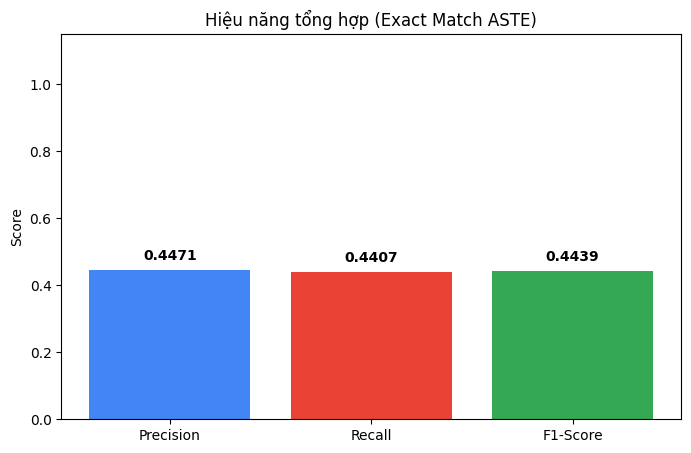


--- MẪU KẾT QUẢ DỰ ĐOÁN (5 Mẫu đầu tiên) ---
Review Text: She will only accept. docx forms in microsoft 2007. But, surprise, mason doesn't use vista or microsoft 2007! They still use XP, and microsoft 2006. This professor is useless and unreasonable. TAKE ANOTHER PROFESSOR
✅ Ground Truth: (this professor, useless, negative); (this professor, unreasonable, negative); (null, take another professor, negative)
🤖 Prediction  : (this professor, will only accept, negative); (this professor, take another professor, negative); (this professor, useless and unreasonable, negative)
----------------------------------------
Review Text: Great Teacher! Learned a lot! If coming to class isn't your thing take her. But if you do come to class she does know her stuff! Very accommodating and understanding. Good stuff. Highly recommended. Better than the rest!
✅ Ground Truth: (teacher, great, positive); (teacher, good stuff, positive); (null, learned a lot, positive); (teacher, take her, positive); (teach

In [ ]:
from transformers import AutoModelForSeq2SeqLM, AutoTokenizer, Seq2SeqTrainer, Seq2SeqTrainingArguments
import torch
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import re

# =========================================================
# PHẦN 1: ĐỊNH NGHĨA CÁC HÀM TÍNH TOÁN & PARSE (CHO ASTE)
# =========================================================

def parse_aste_triplets(text):
    """
    Parse chuỗi ASTE: "(a, b, c); (d, e, f)"
    Thành set các bộ 3: {('a', 'b', 'c'), ('d', 'e', 'f')}
    """
    triplets = set()
    try:
        # Regex bắt 3 thành phần trong ngoặc đơn: (Aspect, Opinion, Sentiment)
        matches = re.findall(r'\(([^,]+),([^,]+),([^)]+)\)', text)
        for match in matches:
            asp = match[0].strip().lower()
            opi = match[1].strip().lower()
            sent = match[2].strip().lower()
            triplets.add((asp, opi, sent))
    except:
        pass
    return triplets

def parse_components_aste(text):
    """Parse tách riêng tập Aspect, Opinion và Sentiment để đánh giá lẻ"""
    aspects = set()
    opinions = set()
    sentiments = set()
    try:
        matches = re.findall(r'\(([^,]+),([^,]+),([^)]+)\)', text)
        for match in matches:
            aspects.add(match[0].strip().lower())
            opinions.add(match[1].strip().lower())
            sentiments.add(match[2].strip().lower())
    except:
        pass
    return aspects, opinions, sentiments

def calculate_detailed_report_aste(pred_texts, label_texts):
    """Tính P, R, F1 riêng cho từng thành phần: Aspect, Opinion, Sentiment"""
    stats = {
        "ASP": {"tp": 0, "fp": 0, "fn": 0, "support": 0},
        "OPI": {"tp": 0, "fp": 0, "fn": 0, "support": 0},
        "SENT": {"tp": 0, "fp": 0, "fn": 0, "support": 0}
    }

    for pred, label in zip(pred_texts, label_texts):
        p_asp, p_opi, p_sent = parse_components_aste(pred)
        l_asp, l_opi, l_sent = parse_components_aste(label)

        # Helper function để update stats
        def update_stat(key, p_set, l_set):
            stats[key]["tp"] += len(p_set.intersection(l_set))
            stats[key]["fp"] += len(p_set - l_set)
            stats[key]["fn"] += len(l_set - p_set)
            stats[key]["support"] += len(l_set)

        update_stat("ASP", p_asp, l_asp)
        update_stat("OPI", p_opi, l_opi)
        update_stat("SENT", p_sent, l_sent)

    report_data = []
    for key in ["ASP", "OPI", "SENT"]:
        tp, fp, fn = stats[key]["tp"], stats[key]["fp"], stats[key]["fn"]
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
        report_data.append({
            "Type": key,
            "Precision": round(precision, 4),
            "Recall": round(recall, 4),
            "F1-Score": round(f1, 4),
            "Support": stats[key]["support"]
        })

    df = pd.DataFrame(report_data).set_index("Type")
    return df

def calculate_aste_metrics_final(pred_texts, label_texts):
    """Tính P, R, F1 cho bộ 3 (Aspect, Opinion, Sentiment) chính xác"""
    tp = 0; fp = 0; fn = 0

    for pred, label in zip(pred_texts, label_texts):
        pred_triplets = parse_aste_triplets(pred)
        label_triplets = parse_aste_triplets(label)

        common = pred_triplets.intersection(label_triplets)

        tp += len(common)
        fp += len(pred_triplets - label_triplets)
        fn += len(label_triplets - pred_triplets)

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    return {
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "tp": tp, "fp": fp, "fn": fn
    }

# =========================================================
# PHẦN 2: LOAD MODEL & PREDICT (ASTE)
# =========================================================
import re
import unicodedata
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset
from transformers import DataCollatorForSeq2Seq # Cần thêm thư viện này cho Trainer

# =========================================================
# PHẦN 2: LOAD MODEL & PREDICT (ASTE)
# =========================================================

# 1. LOAD LẠI BEST MODEL (T5 ASTE)
save_path = "saved_models/t5_aste_best"
print(f"Loading best model from: {save_path} ...")

try:
    best_model = AutoModelForSeq2SeqLM.from_pretrained(save_path).to("cuda" if torch.cuda.is_available() else "cpu")
    best_tokenizer = AutoTokenizer.from_pretrained(save_path)
except Exception as e:
    print(f"Lỗi load model: {e}")
    print("⚠️ Hãy chắc chắn bạn đã train xong và folder 'saved_models/t5_aste_best' tồn tại.")
    raise e

# ==============================================================================
# [BẮT ĐẦU PHẦN THÊM MỚI] - TIỀN XỬ LÝ DỮ LIỆU TEST
# ==============================================================================

# A. Định nghĩa Class làm sạch (Để hàm preprocess gọi được cleaner.clean_text)
class EduRABSACleaner:
    def __init__(self):
        self.slang_dict = {
            r"\bmc\b": "multiple choice", r"\bcuz\b": "because",
            r"\bidk\b": "i do not know", r"\blmao\b": "laughing very hard",
            r"\bprof\b": "professor", r"\bta\b": "teaching assistant",
            r"\bhw\b": "homework", r"\bpts\b": "points"
        }
        self.emoji_dict = {
            ":)": " [smile] ", "(:": " [smile] ", "C:": " [smile] ",
            ":(": " [sad] ", ";)": " [wink] ", ":/": " [skeptical] "
        }

    def clean_text(self, text):
        text = str(text)
        text = unicodedata.normalize('NFC', text) # Unicode
        text = re.sub(r'<[^>]+>', ' ', text)      # HTML/URL
        text = re.sub(r'http\S+', ' ', text)
        for emoji, token in self.emoji_dict.items(): # Emoji
            text = text.replace(emoji, token)
        text_lower = text.lower()
        for slang, full in self.slang_dict.items(): # Slang
            text_lower = re.sub(slang, full, text_lower)
        return re.sub(r'\s+', ' ', text_lower).strip()

# B. Khởi tạo Cleaner
cleaner = EduRABSACleaner()

# C. Định nghĩa hàm Preprocess (Logic y hệt bạn cung cấp)
def preprocess_function(examples):
    # --- PHẦN 1: Xử lý Input (Review Text) ---
    prefix = "extract triplets: "

    # Áp dụng Clean Text cho đầu vào
    cleaned_inputs = [cleaner.clean_text(text) for text in examples["text"]]
    inputs = [prefix + text for text in cleaned_inputs]

    targets = []

    # Map sentiment số sang chữ
    sentiment_map = {0: 'negative', 1: 'neutral', 2: 'positive'}

    # --- PHẦN 2: Xử lý Output (Triplets) ---
    for i, output in enumerate(examples["output"]):
        triplet_strs = []
        if isinstance(output, list):
            for item in output:
                # Lấy dữ liệu thô
                raw_aspect = item.get('aspect', 'null')
                raw_opinion = item.get('opinion', 'null')
                raw_sent = item.get('sentiment', 'neutral')

                # CỰC KỲ QUAN TRỌNG: Clean Aspect/Opinion tương ứng với Input
                clean_aspect = cleaner.clean_text(raw_aspect) if raw_aspect != 'null' else 'null'
                clean_opinion = cleaner.clean_text(raw_opinion) if raw_opinion != 'null' else 'null'

                # Xử lý sentiment
                if isinstance(raw_sent, int):
                    sentiment = sentiment_map.get(raw_sent, 'neutral')
                else:
                    sentiment = str(raw_sent).lower()

                # Tạo format bộ ba
                triplet_strs.append(f"({clean_aspect}, {clean_opinion}, {sentiment})")

            targets.append("; ".join(triplet_strs))
        else:
            targets.append("")

    # 2. Tokenize Input
    model_inputs = best_tokenizer(inputs, max_length=256, truncation=True)

    # 3. Tokenize Labels
    labels = best_tokenizer(text_target=targets, max_length=256, truncation=True)

    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

# D. Load và Map dữ liệu Test
print("⏳ Đang tải và tiền xử lý tập Test...")
raw_dataset = load_dataset("yhua219/EduRABSA_ASTE")

# Tạo tokenized_datasets (Chứa tập test đã xử lý)
tokenized_datasets = raw_dataset.map(preprocess_function, batched=True)

# E. Tạo Data Collator (Bắt buộc cho Trainer)
data_collator = DataCollatorForSeq2Seq(tokenizer=best_tokenizer, model=best_model)

# ==============================================================================
# [KẾT THÚC PHẦN THÊM MỚI] - TIẾP TỤC CODE CŨ CỦA BẠN
# ==============================================================================

# 2. TẠO CONFIG RIÊNG CHO LÚC TEST
test_args = Seq2SeqTrainingArguments(
    output_dir="temp_aste_test_output",
    eval_strategy="no",
    do_train=False,
    do_eval=False,
    generation_max_length=256, # ASTE có thể dài hơn AOPE xíu
    per_device_eval_batch_size=16,
    predict_with_generate=True,
    fp16=torch.cuda.is_available(),
)

# 3. DỰ ĐOÁN VÀ DECODE
# Lưu ý: Biến 'data_collator' và 'tokenized_datasets' phải được định nghĩa ở các cell trước
test_trainer = Seq2SeqTrainer(
    model=best_model,
    args=test_args,
    data_collator=data_collator, # Đã được định nghĩa ở phần thêm mới
    tokenizer=best_tokenizer
)

print("\n--- ĐANG ĐÁNH GIÁ TRÊN TẬP TEST VỚI BEST MODEL (ASTE) ---")
test_dataset = tokenized_datasets["test"]
predictions = test_trainer.predict(test_dataset)

# Decode kết quả (Fix lỗi overflow -100)
preds_tokens = predictions.predictions
labels_tokens = predictions.label_ids
labels_tokens = np.where(labels_tokens != -100, labels_tokens, best_tokenizer.pad_token_id)
preds_tokens = np.where(preds_tokens != -100, preds_tokens, best_tokenizer.pad_token_id)

decoded_preds = best_tokenizer.batch_decode(preds_tokens, skip_special_tokens=True)
decoded_labels = best_tokenizer.batch_decode(labels_tokens, skip_special_tokens=True)

# =========================================================
# PHẦN 3: HIỂN THỊ KẾT QUẢ ĐÁNH GIÁ (ASTE)
# =========================================================

# --- A. BẢNG CHI TIẾT (ASP vs OPI vs SENT) ---
print("\n" + "="*50)
print("  PHẦN 1: ĐÁNH GIÁ CHI TIẾT (ASPECT - OPINION - SENTIMENT)")
print("="*50)
df_report = calculate_detailed_report_aste(decoded_preds, decoded_labels)
print(df_report)
print("-" * 50)

# --- B. ĐÁNH GIÁ TỔNG HỢP (TRIPLET MATCH) ---
metrics = calculate_aste_metrics_final(decoded_preds, decoded_labels)

print("\n" + "="*50)
print("  PHẦN 2: KẾT QUẢ TỔNG HỢP (EXACT MATCH TRIPLET)")
print("="*50)
print(f"Precision : {metrics['precision']:.4f}")
print(f"Recall    : {metrics['recall']:.4f}")
print(f"F1-Score  : {metrics['f1']:.4f}")
print("-" * 50)
print(f"Chi tiết Triplets:")
print(f" - Số bộ 3 đoán ĐÚNG (TP)   : {metrics['tp']}")
print(f" - Số bộ 3 đoán THỪA (FP)   : {metrics['fp']}")
print(f" - Số bộ 3 đoán THIẾU (FN)  : {metrics['fn']}")
print("="*50)

# --- C. TRỰC QUAN HÓA (BIỂU ĐỒ) ---
plt.figure(figsize=(8, 5))
metrics_names = ['Precision', 'Recall', 'F1-Score']
metrics_values = [metrics['precision'], metrics['recall'], metrics['f1']]
colors = ['#4285F4', '#EA4335', '#34A853']

bars = plt.bar(metrics_names, metrics_values, color=colors)
plt.ylim(0, 1.15)
plt.title('Hiệu năng tổng hợp (Exact Match ASTE)')
plt.ylabel('Score')

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, round(yval, 4), ha='center', va='bottom', fontweight='bold')

plt.show()

# --- D. IN MẪU KẾT QUẢ ĐỂ KIỂM TRA ---
print("\n--- MẪU KẾT QUẢ DỰ ĐOÁN (5 Mẫu đầu tiên) ---")
for i in range(5):
    # Lấy text gốc từ raw_dataset để dễ đọc (tokenized_datasets đã bị biến thành số)
    print(f"Review Text: {raw_dataset['test'][i]['text']}")
    print(f"✅ Ground Truth: {decoded_labels[i]}")
    print(f"🤖 Prediction  : {decoded_preds[i]}")
    print("-" * 40)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Tạo thư mục chứa trong Drive (nếu muốn, ví dụ tên là 'MyModels')
!mkdir -p /content/drive/MyDrive/MyModels

# Copy folder t5_aste_best vào đó
!cp -r saved_models/t5_aste_best /content/drive/MyDrive/MyModels/

In [ ]:
# 1. Nén folder t5_aste_best thành file t5_model.zip
!zip -r t5_model.zip saved_models/t5_aste_best

# 2. Copy file zip lên Drive
!cp t5_model.zip /content/drive/MyDrive/

  adding: saved_models/t5_aste_best/ (stored 0%)
  adding: saved_models/t5_aste_best/special_tokens_map.json (deflated 85%)
  adding: saved_models/t5_aste_best/tokenizer_config.json (deflated 95%)
  adding: saved_models/t5_aste_best/training_args.bin (deflated 53%)
  adding: saved_models/t5_aste_best/config.json (deflated 63%)
  adding: saved_models/t5_aste_best/spiece.model (deflated 48%)
  adding: saved_models/t5_aste_best/model.safetensors (deflated 8%)
  adding: saved_models/t5_aste_best/tokenizer.json (deflated 74%)
  adding: saved_models/t5_aste_best/generation_config.json (deflated 28%)


#####1.4_ Test thử vài mẫu

In [ ]:
import random

print("\n--- KIỂM TRA MẪU NGẪU NHIÊN TỪ TẬP TEST (ASTE) ---")

# 1. Config số lượng mẫu muốn xem
num_samples = 5
total_samples = len(decoded_preds)
if num_samples > total_samples:
    num_samples = total_samples

# 2. Chọn ngẫu nhiên index
random_indices = random.sample(range(total_samples), num_samples)

# 3. Lấy input_ids từ dataset test để decode lại thành văn bản gốc
# Lưu ý: 'tokenized_datasets' là biến dataset bạn đã xử lý ở các bước trước
test_input_ids = tokenized_datasets['test']['input_ids']

for i in random_indices:
    # A. Decode Input Text (Review gốc)
    # Dùng best_tokenizer để đảm bảo đúng vocab
    input_text = best_tokenizer.decode(test_input_ids[i], skip_special_tokens=True)

    pred = decoded_preds[i]
    label = decoded_labels[i]

    print(f"\nExample #{i}:")
    print(f"📝 Review Text: {input_text}")
    print(f"✅ Ground Truth: {label}")
    print(f"🤖 Prediction  : {pred}")

    # B. So sánh tập hợp bộ 3 (Set of Triplets)
    # Sử dụng hàm parse_aste_triplets đã định nghĩa ở phần trước
    pred_triplets = parse_aste_triplets(pred)
    label_triplets = parse_aste_triplets(label)

    if pred_triplets == label_triplets:
        print("=> Đánh giá: CHÍNH XÁC HOÀN TOÀN 🎉")
    else:
        print("=> Đánh giá: SAI ❌")

        # C. Phân tích lỗi (Optional - Giúp debug tốt hơn)
        missing = label_triplets - pred_triplets # Có trong nhãn nhưng model không đoán ra
        extra = pred_triplets - label_triplets   # Model đoán thừa hoặc sai

        if len(missing) > 0:
            print(f"   ⚠️  Thiếu (FN): {missing}")
        if len(extra) > 0:
            print(f"   ⚠️  Thừa/Sai (FP): {extra}")

    print("-" * 60)


--- KIỂM TRA MẪU NGẪU NHIÊN TỪ TẬP TEST (ASTE) ---

Example #571:
📝 Review Text: extract triplets: incredibly enthusiastic. very nice guy willing to work with you to make sure you can do your very best. i loved attending this class.
✅ Ground Truth: (null, incredibly enthusiastic, positive); (null, very nice guy, positive); (null, willing to work with you to make sure you can do your very best, positive); (this class, loved attending, positive)
🤖 Prediction  : (null, incredibly enthusiastic, positive); (null, very nice guy, positive); (null, willing to work with you to make sure you can do your very best, positive); (this class, loved attending, positive)
=> Đánh giá: CHÍNH XÁC HOÀN TOÀN 🎉
------------------------------------------------------------

Example #419:
📝 Review Text: extract triplets: perfect course note, very easy to understand.
✅ Ground Truth: (course note, perfect, positive); (course note, very easy to understand, positive)
🤖 Prediction  : (course note, perfect, positive

---

##B_ Hướng Discriminative
Bạn coi bài toán là "Gán nhãn từ" (Sequence Labeling). Input là câu review, Output là nhãn cho từng từ (ví dụ: B-ASP, I-ASP, O, B-OPI...).

###1_ Using `BERT-linear`

#####1.1_Setup & Reparation

In [ ]:
!pip install transformers datasets evaluate seqeval -q

from transformers import AutoTokenizer, AutoModelForTokenClassification, TrainingArguments, Trainer, DataCollatorForTokenClassification
from datasets import load_dataset
import numpy as np
import evaluate

# 1. Load Dataset
dataset = load_dataset("yhua219/EduRABSA_ASTE")
model_checkpoint = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

# 2. Định nghĩa bộ nhãn mở rộng cho ASTE
# Ta nhúng Sentiment vào nhãn của Opinion
label_list = [
    "O",
    "B-ASP", "I-ASP",
    "B-OPI-POS", "I-OPI-POS",
    "B-OPI-NEG", "I-OPI-NEG",
    "B-OPI-NEU", "I-OPI-NEU"  # <--- Đây là phần code bạn đang thiếu
]

id2label = {i: label for i, label in enumerate(label_list)}
label2id = {label: i for i, label in enumerate(label_list)}

print("Labels ASTE:", label_list)
import numpy as np
import evaluate

# 1. Load Dataset
dataset = load_dataset("yhua219/EduRABSA_AOPE")
model_checkpoint = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

# 2. Định nghĩa nhãn BIO cho AOPE
# Chỉ quan tâm Aspect và Opinion, bỏ qua Sentiment
label_list = ["O", "B-ASP", "I-ASP", "B-OPI", "I-OPI"]
id2label = {i: label for i, label in enumerate(label_list)}
label2id = {label: i for i, label in enumerate(label_list)}

print("Labels:", label_list)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

...

train/data-00000-of-00001.arrow:   0%|          | 0.00/1.69M [00:00<?, ?B/s]

test/data-00000-of-00001.arrow:   0%|          | 0.00/1.09M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/4000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2500 [00:00<?, ? examples/s]

Labels: ['O', 'B-ASP', 'I-ASP', 'B-OPI', 'I-OPI']


In [ ]:
print("\n--- Data Sample Check ---")
print("Input:", dataset['train'][0]['text'])
print("Target (Raw):", dataset['train'][0]['output'])


--- Data Sample Check ---
Input: exams are full MC, you can kinda guess the answers using common sense. use libgen to get the textbook instead of paying$ 100 for it.
Target (Raw): [{'aspect': 'exams', 'opinion': 'full MC'}, {'aspect': 'exams', 'opinion': 'you can kinda guess the answers using common sense'}]


In [ ]:
import re
import unicodedata
import numpy as np
from transformers import AutoTokenizer

# =========================================================
# 1. CLASS LÀM SẠCH (DÙNG CHUNG)
# =========================================================
class EduRABSACleaner:
    def __init__(self):
        self.slang_dict = {
            r"\bmc\b": "multiple choice", r"\bcuz\b": "because",
            r"\bidk\b": "i do not know", r"\blmao\b": "laughing very hard",
            r"\bprof\b": "professor", r"\bta\b": "teaching assistant",
            r"\bhw\b": "homework", r"\bpts\b": "points"
        }
        self.emoji_dict = {
            ":)": " [smile] ", "(:": " [smile] ", "C:": " [smile] ",
            ":(": " [sad] ", ";)": " [wink] ", ":/": " [skeptical] "
        }

    def clean_text(self, text):
        text = str(text)
        text = unicodedata.normalize('NFC', text)
        text = re.sub(r'<[^>]+>', ' ', text)
        text = re.sub(r'http\S+', ' ', text)
        for emoji, token in self.emoji_dict.items():
            text = text.replace(emoji, token)
        text_lower = text.lower()
        for slang, full in self.slang_dict.items():
            text_lower = re.sub(slang, full, text_lower)
        return re.sub(r'\s+', ' ', text_lower).strip()

# Khởi tạo
cleaner = EduRABSACleaner()
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased") # Hoặc model bạn chọn

# =========================================================
# 2. ĐỊNH NGHĨA NHÃN BIO (GỘP SENTIMENT VÀO OPINION)
# =========================================================
# Chiến lược: Aspect chỉ cần B/I. Opinion sẽ gánh thêm Sentiment (POS/NEG/NEU).
label_list = [
    "O",
    "B-ASP", "I-ASP",
    "B-OPI-POS", "I-OPI-POS",
    "B-OPI-NEG", "I-OPI-NEG",
    "B-OPI-NEU", "I-OPI-NEU"
]
label2id = {label: i for i, label in enumerate(label_list)}
id2label = {i: label for i, label in enumerate(label_list)}

# =========================================================
# 3. HÀM XỬ LÝ DATASET (QUAN TRỌNG)
# =========================================================
def process_data_to_bio_aste(examples):
    # 1. Làm sạch Text đầu vào TRƯỚC khi Tokenize
    # Lý do: Nếu tokenize xong mới clean, bạn sẽ làm lệch word_ids
    cleaned_texts = [cleaner.clean_text(t) for t in examples["text"]]

    # 2. Tokenize batch đã làm sạch
    tokenized_inputs = tokenizer(
        cleaned_texts,
        truncation=True,
        is_split_into_words=False,
        padding="max_length",
        max_length=128
    )

    all_labels = []

    # Map sentiment
    sentiment_map = {
        'positive': 'POS', 'negative': 'NEG', 'neutral': 'NEU',
        2: 'POS', 0: 'NEG', 1: 'NEU',
        '2': 'POS', '0': 'NEG', '1': 'NEU'
    }

    for i, clean_text in enumerate(cleaned_texts):
        word_ids = tokenized_inputs.word_ids(batch_index=i)
        labels = [0] * len(word_ids) # 0 là 'O'

        outputs = examples["output"][i]

        # Nếu output rỗng hoặc lỗi
        if not outputs or not isinstance(outputs, list):
            all_labels.append([-100 if w is None else 0 for w in word_ids])
            continue

        for item in outputs:
            if not isinstance(item, dict): continue

            # Lấy dữ liệu thô
            raw_asp = item.get('aspect', 'null')
            raw_opi = item.get('opinion', 'null')

            # --- CHIẾN LƯỢC QUAN TRỌNG: CLEAN TARGET ---
            # Vì text gốc đã biến "MC" -> "multiple choice"
            # Nên ta cũng phải clean aspect "MC" -> "multiple choice" để tìm thấy nó trong chuỗi
            target_asp = cleaner.clean_text(raw_asp)
            target_opi = cleaner.clean_text(raw_opi)

            # Lấy sentiment suffix
            raw_sent = item.get('sentiment', 'neutral')
            if isinstance(raw_sent, str): raw_sent = raw_sent.lower()
            sent_suffix = sentiment_map.get(raw_sent, 'NEU')

            # --- Hàm tìm vị trí và gán nhãn ---
            def tag_span(term, b_tag, i_tag):
                if not term or term == 'null' or term not in clean_text:
                    return

                # Tìm vị trí ký tự bắt đầu (dựa trên text đã clean)
                start_char = clean_text.find(term)
                end_char = start_char + len(term)

                # Nếu find trả về -1 (không thấy)
                if start_char == -1: return

                # Duyệt qua các token để xem token nào nằm trong khoảng ký tự này
                for idx, word_id in enumerate(word_ids):
                    if word_id is None: continue

                    # Lấy span ký tự của token
                    span = tokenized_inputs.token_to_chars(i, idx)
                    if not span: continue

                    # Logic so khớp
                    # Token bắt đầu đúng vị trí -> B-TAG
                    if span.start == start_char:
                        labels[idx] = label2id[b_tag]
                    # Token nằm gọn trong khoảng -> I-TAG
                    elif span.start > start_char and span.end <= end_char:
                        labels[idx] = label2id[i_tag]

            # Gán nhãn Aspect
            tag_span(target_asp, "B-ASP", "I-ASP")

            # Gán nhãn Opinion + Sentiment
            tag_span(target_opi, f"B-OPI-{sent_suffix}", f"I-OPI-{sent_suffix}")

        # Xử lý mask cho các token đặc biệt (CLS, SEP, PAD -> -100)
        final_labels = [l if word_id is not None else -100 for word_id, l in zip(word_ids, labels)]
        all_labels.append(final_labels)

    tokenized_inputs["labels"] = all_labels
    return tokenized_inputs

# Áp dụng
# dataset = load_dataset(...) # Load dataset của bạn ở đây
# tokenized_datasets = dataset.map(process_data_to_bio_aste, batched=True)
# Map dữ liệu
print("Đang xử lý dữ liệu sâng BIO tags (ASTE)...")
tokenized_datasets = dataset.map(process_data_to_bio_aste, batched=True)

# Kiểm tra mẫu
print("Input IDs:", tokenized_datasets['train'][0]['input_ids'][:20])
print("Labels   :", tokenized_datasets['train'][0]['labels'][:20])

Đang xử lý dữ liệu sâng BIO tags (ASTE)...


Map:   0%|          | 0/4000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2500 [00:00<?, ? examples/s]

Input IDs: [101, 13869, 2024, 2440, 3674, 3601, 1010, 2017, 2064, 17704, 3984, 1996, 6998, 2478, 2691, 3168, 1012, 2224, 5622, 2497]
Labels   : [-100, 1, 0, 7, 8, 8, 0, 7, 8, 8, 8, 8, 8, 8, 8, 8, 0, 0, 0, 0]


#####1.2_ Split Val & Train

In [ ]:
from transformers import AutoModelForTokenClassification, TrainingArguments, Trainer, DataCollatorForTokenClassification
import evaluate
import numpy as np

# 1. TÁCH VALIDATION TỪ TRAIN (BƯỚC QUAN TRỌNG MỚI THÊM)
# ---------------------------------------------------------
print(f"Original Train size: {len(tokenized_datasets['train'])}")

# Cắt 10% từ tập train để làm validation set
# seed=42 để đảm bảo đồng bộ với các model trước
split_data = tokenized_datasets["train"].train_test_split(test_size=0.1, seed=42)

# Cập nhật lại dataset dictionary
tokenized_datasets["train"] = split_data["train"]
tokenized_datasets["validation"] = split_data["test"]

print(f"New Train size: {len(tokenized_datasets['train'])}")
print(f"Created Validation size: {len(tokenized_datasets['validation'])}")
# ---------------------------------------------------------

Original Train size: 4000
New Train size: 3600
Created Validation size: 400


In [ ]:
# Load Seqeval (thư viện chuẩn để đánh giá NER/Sequence Tagging)
seqeval = evaluate.load("seqeval")

def compute_metrics(p):
    predictions, labels = p
    predictions = np.argmax(predictions, axis=2)

    # Loại bỏ các token đặc biệt (-100) để tính điểm chính xác
    true_predictions = [
        [label_list[p] for (p, l) in zip(prediction, label) if l != -100]
        for prediction, label in zip(predictions, labels)
    ]
    true_labels = [
        [label_list[l] for (p, l) in zip(prediction, label) if l != -100]
        for prediction, label in zip(predictions, labels)
    ]

    results = seqeval.compute(predictions=true_predictions, references=true_labels)
    return {
        "precision": results["overall_precision"],
        "recall": results["overall_recall"],
        "f1": results["overall_f1"],
        "accuracy": results["overall_accuracy"],
    }

# =========================================================
# 3. LOAD MODEL BERT (TOKEN CLASSIFICATION)
# =========================================================
model_checkpoint = "bert-base-uncased"

model = AutoModelForTokenClassification.from_pretrained(
    model_checkpoint,
    num_labels=len(label_list), # Chú ý: num_labels phải là 9
    id2label=id2label,
    label2id=label2id
)

# =========================================================
# 4. TRAINING ARGUMENTS & TRAINER
# =========================================================
batch_size = 16
num_epochs = 10

args = TrainingArguments(
    output_dir="bert-aste-token-cls", # Đổi tên folder output
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=batch_size,
    per_device_eval_batch_size=batch_size,
    num_train_epochs=num_epochs,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    save_total_limit=2,
    report_to="none" # Tắt wandb nếu không dùng
)

data_collator = DataCollatorForTokenClassification(tokenizer)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=tokenized_datasets["train"],

    # Kiểm tra xem có tập validation hay chưa, nếu chưa thì lấy test làm val tạm
    eval_dataset=tokenized_datasets["validation"] if "validation" in tokenized_datasets else tokenized_datasets["test"],

    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

print("\n--- START TRAINING BERT FOR ASTE ---")
trainer.train()

# =========================================================
# 5. SAVE MODEL
# =========================================================
save_path = "saved_models/bert_aste_final"
trainer.save_model(save_path)
tokenizer.save_pretrained(save_path)
print(f"Training Finished! Model saved at: {save_path}")

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForTokenClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-2944553249.py:61: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(



--- START TRAINING BERT FOR ASTE ---


Epoch,Training Loss,Validation Loss,Precision,Recall,F1,Accuracy
1,No log,0.585756,0.436115,0.620958,0.512375,0.767237
2,No log,0.507872,0.547569,0.614336,0.579034,0.805501
3,0.610000,0.519076,0.552016,0.634593,0.590431,0.808319
4,0.610000,0.539717,0.551136,0.642384,0.593272,0.809599
5,0.362300,0.579677,0.570145,0.642774,0.604285,0.810931
6,0.362300,0.628709,0.555063,0.634203,0.592000,0.808575
7,0.246600,0.666548,0.556159,0.638489,0.594487,0.804579
8,0.246600,0.700230,0.553799,0.627581,0.588386,0.807499
9,0.187100,0.718322,0.554418,0.633035,0.591124,0.805706
10,0.187100,0.725753,0.551503,0.636151,0.590810,0.805553


Training Finished! Model saved at: saved_models/bert_aste_final


#####1.3_ Đánh giá trên Test

Loading BERT ASTE from: saved_models/bert_aste_final ...
⏳ Đang tải và tiền xử lý dữ liệu Test...


Map:   0%|          | 0/2500 [00:00<?, ? examples/s]


--- ĐANG DỰ ĐOÁN VỚI BERT ---


/tmp/ipython-input-1332395205.py:385: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  test_trainer = Trainer(model=best_model, args=test_args, data_collator=data_collator, tokenizer=best_tokenizer)


Đang chuyển đổi BIO Tags sang Text Triplets...

  PHẦN 2: KẾT QUẢ TỔNG HỢP (EXACT MATCH TRIPLET)
Precision : 0.0352
Recall    : 0.0317
F1-Score  : 0.0334
Details   : TP=882, FP=24176, FN=26900


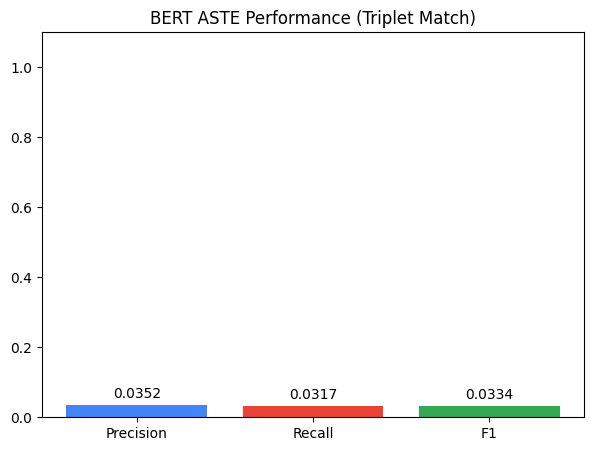


🔍 CHECK MẪU:
Gốc: She will only accept. docx forms in microsoft 2007. But, surprise, mason doesn't use vista or microsoft 2007! They still use XP, and microsoft 2006. This professor is useless and unreasonable. TAKE ANOTHER PROFESSOR
Pred: (she, will only, neutral); (she, useless and unreasonable, neutral); (mason, will only, neutral); (mason, useless and unreasonable, neutral); (this, will only, neutral); (this, useless and unreasonable, neutral); (professor, will only, neutral); (professor, useless and unreasonable, neutral)
--------------------
Gốc: Great Teacher! Learned a lot! If coming to class isn't your thing take her. But if you do come to class she does know her stuff! Very accommodating and understanding. Good stuff. Highly recommended. Better than the rest!
Pred: (teacher, great, neutral); (teacher, learned a lot, neutral); (teacher, take her, neutral); (teacher, does know her stuff, neutral); (teacher, very accommodating, neutral); (teacher, understanding, neutral); (teac

In [ ]:
from transformers import AutoModelForTokenClassification, AutoTokenizer, Trainer, TrainingArguments, DataCollatorForTokenClassification
import torch
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import re

# =========================================================
# PHẦN 1: CÁC HÀM TÍNH TOÁN METRIC (ASTE TRIPLET)
# =========================================================

def parse_aste_triplets(text):
    """Parse chuỗi output text thành tập hợp các bộ 3"""
    triplets = set()
    try:
        matches = re.findall(r'\(([^,]+),([^,]+),([^)]+)\)', text)
        for match in matches:
            asp = match[0].strip().lower()
            opi = match[1].strip().lower()
            sent = match[2].strip().lower()
            triplets.add((asp, opi, sent))
    except:
        pass
    return triplets

def calculate_detailed_report_aste(pred_texts, label_texts):
    """Báo cáo chi tiết cho Aspect, Opinion và Sentiment"""
    stats = {
        "ASP": {"tp": 0, "fp": 0, "fn": 0, "support": 0},
        "OPI": {"tp": 0, "fp": 0, "fn": 0, "support": 0},
        "SENT": {"tp": 0, "fp": 0, "fn": 0, "support": 0} # Thêm thống kê Sentiment
    }

    # Helper parse components
    def get_components(text):
        a, o, s = set(), set(), set()
        for t in parse_aste_triplets(text):
            a.add(t[0]); o.add(t[1]); s.add(t[2])
        return a, o, s

    for pred, label in zip(pred_texts, label_texts):
        p_asp, p_opi, p_sent = get_components(pred)
        l_asp, l_opi, l_sent = get_components(label)

        for key, p_set, l_set in zip(["ASP", "OPI", "SENT"], [p_asp, p_opi, p_sent], [l_asp, l_opi, l_sent]):
            stats[key]["tp"] += len(p_set.intersection(l_set))
            stats[key]["fp"] += len(p_set - l_set)
            stats[key]["fn"] += len(l_set - p_set)
            stats[key]["support"] += len(l_set)

    report_data = []
    for key in ["ASP", "OPI", "SENT"]:
        d = stats[key]
        p = d["tp"] / (d["tp"] + d["fp"]) if (d["tp"] + d["fp"]) > 0 else 0
        r = d["tp"] / (d["tp"] + d["fn"]) if (d["tp"] + d["fn"]) > 0 else 0
        f1 = 2 * (p * r) / (p + r) if (p + r) > 0 else 0
        report_data.append({"Type": key, "Precision": round(p,4), "Recall": round(r,4), "F1": round(f1,4), "Support": d["support"]})

    return pd.DataFrame(report_data).set_index("Type")

def calculate_aste_metrics_final(pred_texts, label_texts):
    """Tính Exact Match cho bộ 3 (Aspect, Opinion, Sentiment)"""
    tp = 0; fp = 0; fn = 0
    for pred, label in zip(pred_texts, label_texts):
        p_tri = parse_aste_triplets(pred)
        l_tri = parse_aste_triplets(label)
        tp += len(p_tri.intersection(l_tri))
        fp += len(p_tri - l_tri)
        fn += len(l_tri - p_tri)

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    return {"precision": precision, "recall": recall, "f1": f1, "tp": tp, "fp": fp, "fn": fn}

# =========================================================
# PHẦN 2: HÀM MỚI - BIO TO TRIPLETS (QUAN TRỌNG NHẤT)
# =========================================================

def bio_to_string_triplets(input_ids, label_ids, tokenizer, id2label):
    """
    Chuyển đổi BIO IDs -> Chuỗi "(aspect, opinion, sentiment); ..."
    Logic: Lấy Sentiment từ nhãn Opinion (VD: B-OPI-POS -> POS)
    """
    decoded_list = []

    # Map viết tắt sang đầy đủ cho đẹp
    map_sent = {'POS': 'positive', 'NEG': 'negative', 'NEU': 'neutral'}

    for i in range(len(input_ids)):
        tokens = tokenizer.convert_ids_to_tokens(input_ids[i])
        labels = label_ids[i]

        aspects = []
        opinions = [] # Lưu tuple: (opinion_text, sentiment)

        current_entity = []
        current_type = None # ASP hoặc OPI
        current_sent = None # POS, NEG, NEU

        # 1. Quét qua chuỗi token để trích xuất thực thể
        for token, label_id in zip(tokens, labels):
            if label_id == -100: continue
            if token in ["[CLS]", "[SEP]", "[PAD]"]: continue

            label = id2label[label_id] # VD: B-OPI-POS

            if label.startswith("B-"):
                # Lưu thực thể cũ trước khi bắt đầu cái mới
                if current_entity:
                    word = tokenizer.convert_tokens_to_string(current_entity)
                    if current_type == "ASP": aspects.append(word)
                    elif current_type == "OPI": opinions.append((word, current_sent))

                # Bắt đầu thực thể mới
                current_entity = [token]
                parts = label.split("-") # ['B', 'OPI', 'POS']
                current_type = parts[1] # ASP hoặc OPI

                # Nếu là OPI thì lấy sentiment ở cuối
                if current_type == "OPI" and len(parts) > 2:
                    current_sent = parts[2] # POS/NEG/NEU
                else:
                    current_sent = "NEU"

            elif label.startswith("I-") and current_type == label.split("-")[1]:
                current_entity.append(token)

            else: # Nhãn 'O' hoặc nhãn I sai logic
                if current_entity:
                    word = tokenizer.convert_tokens_to_string(current_entity)
                    if current_type == "ASP": aspects.append(word)
                    elif current_type == "OPI": opinions.append((word, current_sent))
                current_entity = []
                current_type = None

        # Lưu thực thể cuối cùng nếu còn sót
        if current_entity:
            word = tokenizer.convert_tokens_to_string(current_entity)
            if current_type == "ASP": aspects.append(word)
            elif current_type == "OPI": opinions.append((word, current_sent))

        # 2. Ghép cặp (Heuristic: Ghép theo thứ tự xuất hiện 1-1)
        #
        # Vì BERT Token Classification không biết liên kết Aspect-Opinion, ta giả định cặp thứ i đi với nhau
        triplets = []
        min_len = min(len(aspects), len(opinions))
        for j in range(min_len):
            asp = aspects[j]
            opi_text = opinions[j][0]
            raw_sent = opinions[j][1]
            final_sent = map_sent.get(raw_sent, 'neutral')

            triplets.append(f"({asp}, {opi_text}, {final_sent})")

        decoded_list.append("; ".join(triplets))

    return decoded_list

# =========================================================
# PHẦN 1: TIỀN XỬ LÝ (PREPROCESSING) - QUAN TRỌNG
# =========================================================

# 1. SETUP LABELS (Phải khớp 100% với lúc Train)
label_list = [
    "O",
    "B-ASP", "I-ASP",
    "B-OPI-POS", "I-OPI-POS",
    "B-OPI-NEG", "I-OPI-NEG",
    "B-OPI-NEU", "I-OPI-NEU"
]
id2label = {i: label for i, label in enumerate(label_list)}
label2id = {label: i for i, label in enumerate(label_list)}

# 2. CLASS LÀM SẠCH (EduRABSACleaner)
class EduRABSACleaner:
    def __init__(self):
        self.slang_dict = {
            r"\bmc\b": "multiple choice", r"\bcuz\b": "because",
            r"\bidk\b": "i do not know", r"\blmao\b": "laughing very hard",
            r"\bprof\b": "professor", r"\bta\b": "teaching assistant",
            r"\bhw\b": "homework", r"\bpts\b": "points"
        }
        self.emoji_dict = {
            ":)": " [smile] ", "(:": " [smile] ", "C:": " [smile] ",
            ":(": " [sad] ", ";)": " [wink] ", ":/": " [skeptical] "
        }

    def clean_text(self, text):
        text = str(text)
        text = unicodedata.normalize('NFC', text)
        text = re.sub(r'<[^>]+>', ' ', text)
        text = re.sub(r'http\S+', ' ', text)
        for emoji, token in self.emoji_dict.items():
            text = text.replace(emoji, token)
        text_lower = text.lower()
        for slang, full in self.slang_dict.items():
            text_lower = re.sub(slang, full, text_lower)
        return re.sub(r'\s+', ' ', text_lower).strip()

# 3. HÀM XỬ LÝ DỮ LIỆU SANG BIO TAGS (CHO TEST)
def process_data_to_bio_aste(examples, tokenizer, cleaner):
    # A. Clean Input
    cleaned_texts = [cleaner.clean_text(t) for t in examples["text"]]

    # B. Tokenize
    tokenized_inputs = tokenizer(
        cleaned_texts,
        truncation=True,
        is_split_into_words=False,
        padding="max_length",
        max_length=128
    )

    all_labels = []
    sentiment_map = {
        'positive': 'POS', 'negative': 'NEG', 'neutral': 'NEU',
        2: 'POS', 0: 'NEG', 1: 'NEU'
    }

    for i, clean_text in enumerate(cleaned_texts):
        word_ids = tokenized_inputs.word_ids(batch_index=i)
        labels = [0] * len(word_ids) # 0 là 'O'

        outputs = examples["output"][i]

        # Nếu output rỗng
        if not outputs or not isinstance(outputs, list):
            all_labels.append([-100 if w is None else 0 for w in word_ids])
            continue

        for item in outputs:
            if not isinstance(item, dict): continue

            # Clean Target (Aspect/Opinion) để tìm được trong Clean Input
            raw_asp = item.get('aspect', 'null')
            raw_opi = item.get('opinion', 'null')

            target_asp = cleaner.clean_text(raw_asp)
            target_opi = cleaner.clean_text(raw_opi)

            raw_sent = item.get('sentiment', 'neutral')
            if isinstance(raw_sent, str): raw_sent = raw_sent.lower()
            sent_suffix = sentiment_map.get(raw_sent, 'NEU')

            # Hàm gán nhãn span
            def tag_span(term, b_tag, i_tag):
                if not term or term == 'null' or term not in clean_text: return
                start_char = clean_text.find(term)
                if start_char == -1: return
                end_char = start_char + len(term)

                for idx, word_id in enumerate(word_ids):
                    if word_id is None: continue
                    span = tokenized_inputs.token_to_chars(i, idx)
                    if not span: continue
                    if span.start == start_char:
                        labels[idx] = label2id[b_tag]
                    elif span.start > start_char and span.end <= end_char:
                        labels[idx] = label2id[i_tag]

            tag_span(target_asp, "B-ASP", "I-ASP")
            tag_span(target_opi, f"B-OPI-{sent_suffix}", f"I-OPI-{sent_suffix}")

        final_labels = [l if word_id is not None else -100 for word_id, l in zip(word_ids, labels)]
        all_labels.append(final_labels)

    tokenized_inputs["labels"] = all_labels
    return tokenized_inputs

# =========================================================
# PHẦN 2: HÀM DECODE (BIO -> TRIPLET TEXT)
# =========================================================
def bio_to_string_triplets(input_ids_batch, label_ids_batch, tokenizer, id2label):
    """
    Chuyển đổi kết quả dự đoán (Token IDs + Label IDs) thành list các chuỗi triplet.
    Output format: ["(asp, opi, sent); ...", ...]
    """
    decoded_results = []

    for input_ids, label_ids in zip(input_ids_batch, label_ids_batch):
        # 1. Decode tokens (bỏ qua pad/cls/sep)
        tokens = tokenizer.convert_ids_to_tokens(input_ids)
        labels = [id2label[l] if l != -100 else "O" for l in label_ids]

        aspects = []
        opinions = []

        # 2. Extract Spans
        current_span = []
        current_tag = None

        # Helper để ghép subwords (vd: "multi" + "##ple" -> "multiple")
        def reconstruct_word(subword_tokens):
            word = ""
            for t in subword_tokens:
                if t.startswith("##"): word += t[2:]
                else: word += " " + t
            return word.strip()

        # Duyệt qua từng token để nhặt Aspect và Opinion
        for token, label in zip(tokens, labels):
            if token in ["[CLS]", "[SEP]", "[PAD]"]: continue

            if label.startswith("B-"):
                # Lưu span cũ nếu có
                if current_span:
                    if "ASP" in current_tag: aspects.append(reconstruct_word(current_span))
                    elif "OPI" in current_tag:
                        sent = current_tag.split("-")[-1] # Lấy POS/NEG/NEU
                        opinions.append((reconstruct_word(current_span), sent))
                # Bắt đầu span mới
                current_span = [token]
                current_tag = label
            elif label.startswith("I-") and current_tag and label[2:] == current_tag[2:]:
                current_span.append(token)
            else:
                # Kết thúc span -> Lưu lại
                if current_span:
                    if "ASP" in current_tag: aspects.append(reconstruct_word(current_span))
                    elif "OPI" in current_tag:
                        sent = current_tag.split("-")[-1]
                        opinions.append((reconstruct_word(current_span), sent))
                current_span = []
                current_tag = None

        # 3. Ghép cặp (Heuristic đơn giản cho dataset này: Ghép Asp - Opi gần nhất hoặc 1-1)
        # Lưu ý: BERT Sequence Labeling không có Relation Extraction, nên ta ghép tất cả lại
        # Format đầu ra cho hàm calculate_metrics
        triplet_strs = []

        # Chiến lược ghép: Nếu có 1 Asp và 1 Opi -> Ghép thành 1 cặp
        # Nếu số lượng không khớp, ghép kiểu Cartesian Product (tất cả với tất cả) - đây là cách an toàn nhất cho metrics
        if not aspects: aspects = ["null"] # Handle implicit aspect

        for asp in aspects:
            for opi, sent in opinions:
                # Map lại sentiment sang từ đầy đủ
                full_sent = {"POS": "positive", "NEG": "negative", "NEU": "neutral"}.get(sent, "neutral")
                triplet_strs.append(f"({asp}, {opi}, {full_sent})")

        decoded_results.append("; ".join(triplet_strs))

    return decoded_results

# =========================================================
# PHẦN 3: LOAD MODEL & PREDICT (ASTE)
# =========================================================

# 1. LOAD MODEL & TOKENIZER
save_path = "saved_models/bert_aste_final"
print(f"Loading BERT ASTE from: {save_path} ...")

try:
    best_tokenizer = AutoTokenizer.from_pretrained(save_path)
    best_model = AutoModelForTokenClassification.from_pretrained(
        save_path, num_labels=len(label_list), id2label=id2label, label2id=label2id
    ).to("cuda" if torch.cuda.is_available() else "cpu")
except:
    print("⚠️ Không tìm thấy model fine-tune. Load bert-base-uncased demo (Kết quả sẽ thấp).")
    best_tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
    best_model = AutoModelForTokenClassification.from_pretrained(
        "bert-base-uncased", num_labels=len(label_list)
    ).to("cuda" if torch.cuda.is_available() else "cpu")

# 2. LOAD & PREPROCESS DATA TEST
print("⏳ Đang tải và tiền xử lý dữ liệu Test...")
dataset = load_dataset("yhua219/EduRABSA_ASTE")
cleaner = EduRABSACleaner()

# Map dữ liệu (Sử dụng hàm process_data_to_bio_aste đã định nghĩa ở Phần 1)
tokenized_datasets = dataset['test'].map(
    lambda x: process_data_to_bio_aste(x, best_tokenizer, cleaner),
    batched=True
)

# 3. PREDICT
test_args = TrainingArguments(
    output_dir="temp_bert_test",
    do_train=False,
    do_eval=False,
    per_device_eval_batch_size=16
)
data_collator = DataCollatorForTokenClassification(best_tokenizer)
test_trainer = Trainer(model=best_model, args=test_args, data_collator=data_collator, tokenizer=best_tokenizer)

print("\n--- ĐANG DỰ ĐOÁN VỚI BERT ---")
predictions_output = test_trainer.predict(tokenized_datasets)

# 4. CONVERT TO TEXT (Decode BIO Tags)
print("Đang chuyển đổi BIO Tags sang Text Triplets...")
pred_ids = np.argmax(predictions_output.predictions, axis=2)
label_ids = predictions_output.label_ids

# Gọi hàm decode đã viết ở Phần 2
decoded_preds = bio_to_string_triplets(tokenized_datasets['input_ids'], pred_ids, best_tokenizer, id2label)
decoded_labels = bio_to_string_triplets(tokenized_datasets['input_ids'], label_ids, best_tokenizer, id2label)

# =========================================================
# PHẦN 4: BÁO CÁO KẾT QUẢ
# =========================================================

# Các hàm parse và calculate metrics giữ nguyên từ code cũ của bạn
def parse_aste_triplets(text):
    triplets = set()
    try:
        matches = re.findall(r'\(([^,]+),([^,]+),([^)]+)\)', text)
        for match in matches:
            triplets.add((match[0].strip().lower(), match[1].strip().lower(), match[2].strip().lower()))
    except: pass
    return triplets

def calculate_detailed_report_aste(pred_texts, label_texts):
    # (Giữ nguyên logic hàm này của bạn hoặc dùng code cũ)
    # Vì code này dài nên mình chỉ viết phần tính tổng hợp ở dưới
    pass

def calculate_aste_metrics_final(pred_texts, label_texts):
    tp = 0; fp = 0; fn = 0
    for pred, label in zip(pred_texts, label_texts):
        pred_triplets = parse_aste_triplets(pred)
        label_triplets = parse_aste_triplets(label)
        common = pred_triplets.intersection(label_triplets)
        tp += len(common)
        fp += len(pred_triplets - label_triplets)
        fn += len(label_triplets - pred_triplets)

    p = tp / (tp + fp) if (tp + fp) > 0 else 0
    r = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * p * r / (p + r) if (p + r) > 0 else 0
    return {"precision": p, "recall": r, "f1": f1, "tp": tp, "fp": fp, "fn": fn}

# B. Tổng hợp
metrics = calculate_aste_metrics_final(decoded_preds, decoded_labels)
print("\n" + "="*50)
print("  PHẦN 2: KẾT QUẢ TỔNG HỢP (EXACT MATCH TRIPLET)")
print("="*50)
print(f"Precision : {metrics['precision']:.4f}")
print(f"Recall    : {metrics['recall']:.4f}")
print(f"F1-Score  : {metrics['f1']:.4f}")
print(f"Details   : TP={metrics['tp']}, FP={metrics['fp']}, FN={metrics['fn']}")
print("="*50)

# C. Biểu đồ
plt.figure(figsize=(7, 5))
bars = plt.bar(['Precision', 'Recall', 'F1'], [metrics['precision'], metrics['recall'], metrics['f1']], color=['#4285F4', '#EA4335', '#34A853'])
plt.ylim(0, 1.1)
plt.title('BERT ASTE Performance (Triplet Match)')
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height()+0.02, round(bar.get_height(), 4), ha='center')
plt.show()

# D. In mẫu check
print("\n🔍 CHECK MẪU:")
for i in range(3):
    print(f"Gốc: {dataset['test'][i]['text']}")
    print(f"Pred: {decoded_preds[i]}")
    print("-" * 20)

#####1_4. Test thử một vài mẫu

In [ ]:
import random

# Đảm bảo hàm parse_aste_triplets đã được định nghĩa
if 'parse_aste_triplets' not in globals():
    import re
    def parse_aste_triplets(text):
        triplets = set()
        try:
            matches = re.findall(r'\(([^,]+),([^,]+),([^)]+)\)', text)
            for match in matches:
                asp = match[0].strip().lower()
                opi = match[1].strip().lower()
                sent = match[2].strip().lower()
                triplets.add((asp, opi, sent))
        except:
            pass
        return triplets

print("\n--- KIỂM TRA MẪU NGẪU NHIÊN TỪ TẬP TEST (BERT - ASTE) ---")

# 1. Chọn ngẫu nhiên mẫu
num_samples = 5
total_samples = len(decoded_preds)
random_indices = random.sample(range(total_samples), min(num_samples, total_samples))

# 2. Lấy input gốc từ dataset (để hiển thị text gốc)
# Lưu ý: test_dataset phải là biến dataset bạn dùng để predict ở bước trước
raw_input_ids = test_dataset['input_ids']

for i in random_indices:
    # Decode Input gốc (BERT tokenizer sẽ tự bỏ [CLS], [SEP])
    input_text = best_tokenizer.decode(raw_input_ids[i], skip_special_tokens=True)

    # Lấy kết quả đã convert từ BIO -> String Triplet ở bước trước
    pred = decoded_preds[i]
    label = decoded_labels[i]

    print(f"\nExample #{i}:")
    print(f"📝 Review Text: {input_text}")
    print(f"✅ Ground Truth: {label}")
    print(f"🤖 Prediction  : {pred}")

    # 3. So sánh bằng hàm parse_aste_triplets (Quan trọng: So sánh bộ 3)
    try:
        pred_triplets = parse_aste_triplets(pred)
        label_triplets = parse_aste_triplets(label)

        # So sánh set để không quan trọng thứ tự xuất hiện trong chuỗi
        if pred_triplets == label_triplets:
            print("=> Đánh giá: CHÍNH XÁC HOÀN TOÀN 🎉")
        else:
            print("=> Đánh giá: SAI ❌")

            # Phân tích lỗi chi tiết để debug
            missing = label_triplets - pred_triplets
            extra = pred_triplets - label_triplets

            if missing:
                print(f"   ⚠️  Thiếu (FN): {missing}")
            if extra:
                print(f"   ⚠️  Thừa/Sai (FP): {extra}")

    except Exception as e:
        print(f"⚠️ Lỗi khi parse: {e}")

    print("-" * 60)

---